In [ ]:
#  بسم الله الرحمن الرحیم  

In [ ]:
#  کد ایجاد انبوه

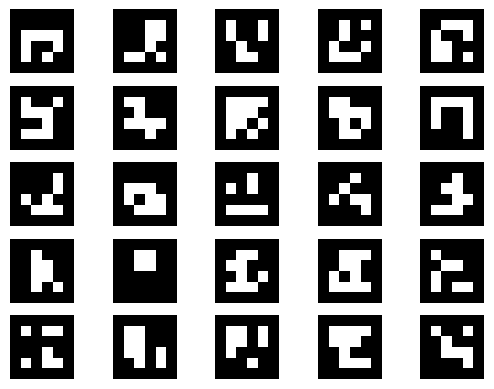

In [29]:
import cv2 
import numpy as np
import cv2.aruco as aruco
import matplotlib.pyplot as plt
import matplotlib as mpl


# Load the predefined dictionary DICT_4X4_100 or 50
aruco_dict = cv2.aruco.getPredefinedDictionary(cv2.aruco.DICT_4X4_50) #size is 4 by 4 and number is 50 - faster
marker_size = 200


fig = plt.figure()
nx = 5
ny = 5
for marker_id in range(1, nx*ny+1):
    ax = fig.add_subplot(ny,nx, marker_id)
    Marker_zero = np.zeros((marker_size, marker_size), dtype=np.uint8) #
    markerImage = cv2.aruco.generateImageMarker(aruco_dict,marker_id, marker_size,Marker_zero, 1) #marker_size is the number of pixels
       
    plt.imshow(markerImage, cmap = mpl.cm.gray, interpolation = "nearest")
    ax.axis("off")

plt.savefig("markers.jpeg")
plt.show()


In [30]:
# توابع

In [31]:
# تابع یک _ شناسایی نشانگر
def marker_detect(image):
    # Convert the image to grayscale
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    aruco_dict = cv2.aruco.getPredefinedDictionary(cv2.aruco.DICT_4X4_50)  # 100 or 50 
    parameters = cv2.aruco.DetectorParameters()

    # Create the ArUco detector
    detector = cv2.aruco.ArucoDetector(aruco_dict, parameters) #********
    # Detect the markers
    corners, ids, rejected = detector.detectMarkers(gray) #***
    # Print the detected markers
    #print("Detected markers:", corners, ids) # print all data <-----
    if ids is not None:
        cv2.aruco.drawDetectedMarkers(image, corners, ids)
        cv2.imshow('Detected Markers', image)
        cv2.waitKey(0)
        cv2.destroyAllWindows()
        
        plt.close()
        plt.imshow(image, cmap = mpl.cm.gray, interpolation = "nearest")
        ax.axis("off")
        plt.savefig("markers_ids.jpeg")
        plt.show()
        
    return corners, ids

In [32]:
#  تشخیص گوشه های نشانگر

In [33]:
# تابع دو _ #  تشخیص گوشه های نشانگر
def marker_corner(corners,ids):
    # verify *at least* one ArUco marker was detected
    if len(corners) > 0:
    # flatten the ArUco IDs list
        ids = ids.flatten()
        print(ids)
        corners_dic={} ; i=0
        # loop over the detected ArUCo corners
        for corner in corners:
            # extract the marker corners (which are always returned in
            # top-left, top-right, bottom-right, and bottom-left order)
            print(corner)
            topLeft = corner[0][0]
            topRight= corner[0][1]
            bottomRight=corner[0][2]
            bottomLeft=corner[0][3]
            print(topLeft,topRight,bottomRight,bottomLeft)
            # convert each of the (x, y)-coordinate pairs to integers
            topRight = (int(topRight[0]), int(topRight[1]))
            bottomRight = (int(bottomRight[0]), int(bottomRight[1]))
            bottomLeft = (int(bottomLeft[0]), int(bottomLeft[1]))
            topLeft = (int(topLeft[0]), int(topLeft[1]))
            print(topLeft,topRight,bottomRight,bottomLeft)
            # (307, 118) (307, 158) (227, 160) (231, 121) = example
            corners_dic[ids[i]]=(topLeft,topRight,bottomRight,bottomLeft)
            i=i+1
            
    return corners_dic

In [34]:
# تابع سوم _ نمایش نشانگرها 
def draw_marker(image,corners_dic):
    # draw the bounding box of the ArUCo detection
    for ids,corner in corners_dic.items():
        topLeft,topRight,bottomRight,bottomLeft=corner
        cv2.line(image, topLeft, topRight, (0, 255, 0), 2)
        cv2.line(image, topRight, bottomRight, (0, 255, 0), 2)
        cv2.line(image, bottomRight, bottomLeft, (0, 255, 0), 2)
        cv2.line(image, bottomLeft, topLeft, (0, 255, 0), 2)
        # compute and draw the center (x, y)-coordinates of the ArUco
        # marker
        cX = int((topLeft[0] + bottomRight[0]) / 2.0)
        cY = int((topLeft[1] + bottomRight[1]) / 2.0)
        cv2.circle(image, (cX, cY), 4, (0, 0, 255), -1)
        # draw the ArUco marker ID on the image
        cv2.putText(image, str(ids),
            (topLeft[0], topLeft[1] - 15), cv2.FONT_HERSHEY_SIMPLEX,
            0.5, (0, 0, 255), 2)
    
    print("[INFO] ArUco marker ID: {}".format(ids))
    # show the output image
    cv2.imshow("Image", image)
    cv2.waitKey(0)

    plt.close()
    plt.imshow(image, cmap = mpl.cm.gray, interpolation = "nearest")
    ax.axis("off")
    plt.savefig("markers_bbox.jpeg")
    plt.show()

----------markers--------------


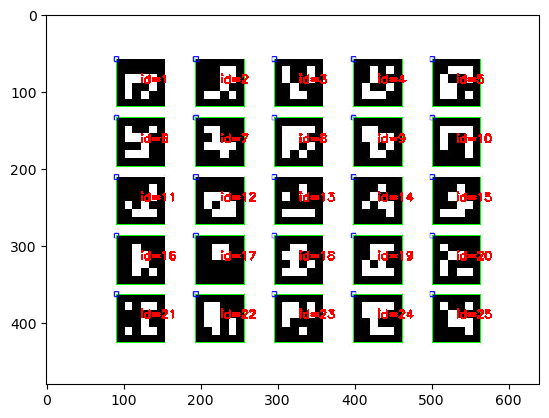

----------Corners--------------
[25 24 23 22 21 20 19 18 17 16 10  9  8  7  6 15 14 13 12 11  5  4  3  2
  1]
[[[501. 363.]
  [564. 363.]
  [564. 426.]
  [501. 426.]]]
[501. 363.] [564. 363.] [564. 426.] [501. 426.]
(501, 363) (564, 363) (564, 426) (501, 426)
[[[399. 363.]
  [462. 363.]
  [462. 426.]
  [399. 426.]]]
[399. 363.] [462. 363.] [462. 426.] [399. 426.]
(399, 363) (462, 363) (462, 426) (399, 426)
[[[296. 363.]
  [359. 363.]
  [359. 426.]
  [296. 426.]]]
[296. 363.] [359. 363.] [359. 426.] [296. 426.]
(296, 363) (359, 363) (359, 426) (296, 426)
[[[194. 363.]
  [257. 363.]
  [257. 426.]
  [194. 426.]]]
[194. 363.] [257. 363.] [257. 426.] [194. 426.]
(194, 363) (257, 363) (257, 426) (194, 426)
[[[ 91. 363.]
  [154. 363.]
  [154. 426.]
  [ 91. 426.]]]
[ 91. 363.] [154. 363.] [154. 426.] [ 91. 426.]
(91, 363) (154, 363) (154, 426) (91, 426)
[[[501. 287.]
  [564. 287.]
  [564. 350.]
  [501. 350.]]]
[501. 287.] [564. 287.] [564. 350.] [501. 350.]
(501, 287) (564, 287) (564, 350) (50

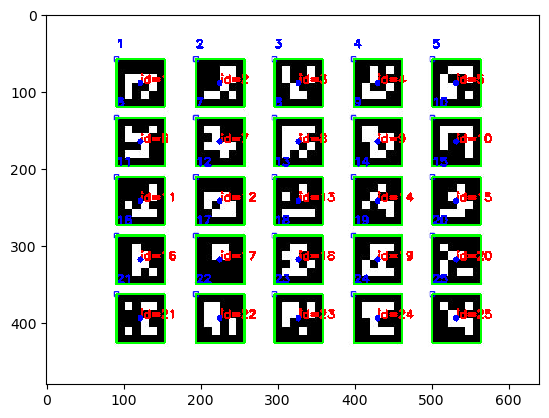

{25: ((501, 363), (564, 363), (564, 426), (501, 426)), 24: ((399, 363), (462, 363), (462, 426), (399, 426)), 23: ((296, 363), (359, 363), (359, 426), (296, 426)), 22: ((194, 363), (257, 363), (257, 426), (194, 426)), 21: ((91, 363), (154, 363), (154, 426), (91, 426)), 20: ((501, 287), (564, 287), (564, 350), (501, 350)), 19: ((399, 287), (462, 287), (462, 350), (399, 350)), 18: ((296, 287), (359, 287), (359, 350), (296, 350)), 17: ((194, 287), (257, 287), (257, 350), (194, 350)), 16: ((91, 287), (154, 287), (154, 350), (91, 350)), 10: ((501, 134), (564, 134), (564, 197), (501, 197)), 9: ((399, 134), (462, 134), (462, 197), (399, 197)), 8: ((296, 134), (359, 134), (359, 197), (296, 197)), 7: ((194, 134), (257, 134), (257, 197), (194, 197)), 6: ((91, 134), (154, 134), (154, 197), (91, 197)), 15: ((501, 211), (564, 211), (564, 273), (501, 273)), 14: ((399, 211), (462, 211), (462, 273), (399, 273)), 13: ((296, 211), (359, 211), (359, 273), (296, 273)), 12: ((194, 211), (257, 211), (257, 27

In [35]:
# تابع اصلی 
# ==================  MAIN ================
import cv2
import numpy as np
import cv2.aruco as aruco
import matplotlib.pyplot as plt
import matplotlib as mpl

# Load the image
image = cv2.imread('markers.jpeg') # C:/Users/my_name_user_in_windowd/markers_1.jpeg'
cv2.imshow("ArUco Marker", image);cv2.waitKey(0);cv2.destroyAllWindows()

print("----------markers--------------")
corners, ids = marker_detect(image)
print("----------Corners--------------")
corners_dic = marker_corner(corners,ids)

draw_marker(image,corners_dic)

print(corners_dic)

In [ ]:
# برنامه برای نمایش نشانگرها در فریم های دریافتی از وب کم 
import cv2
import time
import numpy as np
import cv2.aruco as aruco
import matplotlib.pyplot as plt
import matplotlib as mpl

# Initialize the webcam (device index 0 for default webcam)
cap = cv2.VideoCapture(0)

if not cap.isOpened():
    print("Error: Could not open webcam.")
    exit()

try:
    while True:
        # Capture a frame from the webcam
        ret, frame = cap.read()
        if not ret:
            print("Error: Could not read frame.")
            break
        
        # Display the captured frame in a window
        cv2.imshow("Webcam Feed", frame)
        #cv2.imshow("ArUco Marker", image);cv2.waitKey(0);cv2.destroyAllWindows()
        image=frame
        corners, ids = marker_detect(image)
        corners_dic = marker_corner(corners,ids)
        #print(corners_dic)
        draw_marker(image,corners_dic)
        
        
        
       
        
        # Wait for 1 second or until 'q' is pressed
        if cv2.waitKey(1000) & 0xFF == ord('q'):
            break

except KeyboardInterrupt:
    print("Capture stopped by user.")

# Release the webcam and close all OpenCV windows
cap.release()
cv2.destroyAllWindows()
